# Delft3D model builder workflow with D-HyDAMO

## Preprocessing
- Add the `z` geometry coordinate of `profielpunt` from `hoogte`
- Load 1D network `hydroobject`, structures (), crosssection profiles () from the Geopackage file
- Load storage nodes/storage areas from Shapefile, and storage characteristics from CSV
- Convert all structures into dataframe: `hydamo.<structure>` -> `hydamo.structures` -> df, all crosssection profiles into `hydamo.crosssections` and attach to `hydamo.branches`
- Load observation points from Shapefile and convert to `hydamo.observationpoints`

## Model builder
- Initialize FMMmodel
- Create 1D mesh from the 1D network and structures
- Create refinement spaces for all manholes
- Load the 2D simulation region from Shapefile and create 2D mesh
- Refine 2D mesh with 1D network
- Create 1D-2D link from the river/canals and manholes

# Rainfall runoff model
- Load 3 three raster files: landuses, soiltype (for unpaved nodes), DEM
- Setup RR-model params
- Create unpaved nodes, paved nodes, open water nodes, greenhouse nodes
- Create RR boundaries

# External forcing
- Add boundary conditions: constant (from dataset), timeseries, QH-relation
- Add initial water depth conditions of river/canal and storage nodes/areas

# Export the model
- Initialize DIMR with `run_dimr.bat` path to write MDU files
- If RR/RTC are used, initialize its writer (if needed) and export its model

In [1]:
import warnings
from pathlib import Path
import folium
import shutil
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
import rasterio

warnings.simplefilter(action='ignore', category=FutureWarning)

# and from hydrolib-core
from hydrolib.core.dflowfm.crosssection.models import CrossDefModel, CrossLocModel
from hydrolib.core.dflowfm.ext.models import ExtModel, Meteo, MeteoForcingFileType
from hydrolib.core.dflowfm.extold.models import (
    ExtOldModel, ExtOldForcing, ExtOldQuantity, 
    ExtOldFileType, ExtOldMethod
)
from hydrolib.core.dflowfm.bc.models import ForcingModel, TimeSeries, QuantityUnitPair
from hydrolib.core.dflowfm.friction.models import FrictionModel
from hydrolib.core.dflowfm.inifield.models import DiskOnlyFileModel, IniFieldModel
from hydrolib.core.dflowfm.mdu.models import FMModel, GroundWater, InfiltrationMethod
from hydrolib.core.dflowfm.obs.models import ObservationPointModel
from hydrolib.core.dflowfm.onedfield.models import OneDFieldModel, OneDFieldGlobal, OneDFieldBranch
from hydrolib.core.dflowfm.inifield.models import IniFieldModel, InitialField, DiskOnlyFileModel
from hydrolib.core.dflowfm.storagenode.models import StorageNodeModel
from hydrolib.core.dflowfm.structure.models import StructureModel
from hydrolib.core.dflowfm.common.models import Operand
from hydrolib.core.dimr.models import DIMR, FMComponent

import meshkernel as mk
from meshkernel.py_structures import DeleteMeshOption
from hydrolib.dhydamo.converters.df2hydrolibmodel import Df2HydrolibModel
from hydrolib.dhydamo.core.drr import DRRModel
from hydrolib.dhydamo.core.drtc import DRTCModel
from hydrolib.dhydamo.core.hydamo import HyDAMO
from hydrolib.dhydamo.geometry import mesh
from hydrolib.dhydamo.geometry.viz import plot_network, point_layer
from hydrolib.dhydamo.io.dimrwriter import DIMRWriter
from hydrolib.dhydamo.io.drrwriter import DRRWriter
from hydrolib.dhydamo.logging import configure_logging

In [ ]:
# path to the package containing the dummy-data
import os
print(os.getcwd())
data_path = Path("./template/datasets").resolve()
print(data_path)
assert data_path.exists()

TwoD = True
RR = False
RTC = False

output_path = Path(data_path) / "dfm"

G:\workspace\github\HYDROLIB\hydrolib\notebooks
G:\workspace\github\HYDROLIB\hydrolib\tests\data\template\datasets


In [3]:
# The template generator writes the profile-point elevation to the `hoogte`
# attribute but leaves the geometry's z at 0.0. D-HyDAMO reads z from the
# geometry and ignores `hoogte`, so lift `hoogte` into z before loading.
# Only x/y feed the GPKG r-tree, so the spatial index stays valid.
import math
import sqlite3
import struct

_ENVELOPE_LEN = {0: 0, 1: 32, 2: 48, 3: 48, 4: 64}


def _split_gpkg_blob(blob):
    header_len = 8 + _ENVELOPE_LEN[(blob[3] >> 1) & 0x07]
    wkb = blob[header_len:]
    byte_order = "<" if wkb[0] else ">"
    wkb_type = struct.unpack(byte_order + "I", wkb[1:5])[0]
    return blob[:header_len], wkb, byte_order, wkb_type

def _point_coords(blob):
    _, wkb, byte_order, _ = _split_gpkg_blob(blob)
    return struct.unpack(byte_order + "ddd", wkb[5:29])

def _with_z(blob, z):
    header, wkb, byte_order, wkb_type = _split_gpkg_blob(blob)
    if wkb_type != 1001:
        raise ValueError(f"expected PointZ (1001), got wkb type {wkb_type}")
    x, y, _ = struct.unpack(byte_order + "ddd", wkb[5:29])
    return header + wkb[:5] + struct.pack(byte_order + "ddd", x, y, z)

def set_profielpunt_z_from_hoogte(gpkg_path):
    """Copy `hoogte` into the z-coordinate of every profielpunt geometry."""
    con = sqlite3.connect(gpkg_path)
    try:
        # GDAL's r-tree triggers call these; plain sqlite3 does not provide them.
        con.create_function("ST_IsEmpty", 1, lambda blob: 0)
        for name, index in (("MinX", 0), ("MaxX", 0), ("MinY", 1), ("MaxY", 1)):
            con.create_function(
                f"ST_{name}", 1, lambda blob, i=index: _point_coords(blob)[i]
            )

        rows = con.execute("SELECT fid, code, hoogte, geom FROM profielpunt").fetchall()
        invalid = [
            code for _, code, hoogte, _ in rows
            if hoogte is None or not math.isfinite(hoogte)
        ]
        if invalid:
            raise ValueError(f"profielpunt has missing/invalid 'hoogte': {invalid}")

        con.executemany(
            "UPDATE profielpunt SET geom = ? WHERE fid = ?",
            [(_with_z(geom, float(hoogte)), fid) for fid, _, hoogte, geom in rows],
        )
        con.commit()
    finally:
        con.close()
    return len(rows)

npoints = set_profielpunt_z_from_hoogte(str(data_path / "template.gpkg"))
print(f"Set z from 'hoogte' for {npoints} profile points")


Set z from 'hoogte' for 28 profile points


In [4]:
gpkg_file = str(data_path / "template.gpkg")
storagenode_path = data_path / "storageareas"
storagenode_shp = storagenode_path / "storagenodes.shp"
hydamo = HyDAMO()

# read structures
hydamo.branches.read_gpkg_layer(gpkg_file, layer_name="hydroobject", index_col="code")
hydamo.weirs.read_gpkg_layer(gpkg_file, layer_name="Stuw", index_col="code")
hydamo.opening.read_gpkg_layer(gpkg_file, layer_name="kunstwerkopening")
hydamo.management_device.read_gpkg_layer(gpkg_file, layer_name="regelmiddel")
hydamo.snap_to_branch_and_drop(hydamo.weirs, hydamo.branches, snap_method="overal", maxdist=15, drop_related=True)

# read bridges
hydamo.bridges.read_gpkg_layer(gpkg_file, layer_name="brug", index_col="code")
hydamo.snap_to_branch_and_drop(hydamo.bridges, hydamo.branches, snap_method="overal", maxdist=15, drop_related=True)

# read crossection
hydamo.profile.read_gpkg_layer(
    gpkg_file,
    layer_name="ProfielPunt",
    groupby_column="profiellijnid",
    order_column="codevolgnummer",
    id_col="code",
    index_col="code",
    check_3d=True
)
hydamo.profile_roughness.read_gpkg_layer(gpkg_file, layer_name="RuwheidProfiel")
hydamo.profile_line.read_gpkg_layer(gpkg_file, layer_name="profiellijn")
hydamo.profile_group.read_gpkg_layer(gpkg_file, layer_name="profielgroep")
hydamo.profile.drop("code", axis=1, inplace=True)
hydamo.profile["code"] = hydamo.profile["profiellijnid"]
hydamo.snap_to_branch_and_drop(hydamo.profile, hydamo.branches, snap_method="intersecting", drop_related=True)

crosssection_path = data_path / "crosssection"
circle_defs = pd.read_csv(crosssection_path / "circle_definition.csv")
rectangle_defs = pd.read_csv(crosssection_path / "rectangle_definition.csv")
trapezium_defs = pd.read_csv(crosssection_path / "trapezium_definition.csv")
yz_defs = pd.read_csv(crosssection_path / "yz_definition.csv")
zw_defs = pd.read_csv(crosssection_path / "zw_definition.csv")
crosssection_map = pd.read_csv(crosssection_path / "crosssection_location.csv")

for _, r in circle_defs.iterrows():
    hydamo.crosssections.add_circle_definition(
        diameter=float(r["diameter"]),
        roughnesstype=r["roughnesstype"],
        roughnessvalue=float(r["roughnessvalue"]),
        name=r["name"],
    )

for _, r in rectangle_defs.iterrows():
    hydamo.crosssections.add_rectangle_definition(
        height=float(r["height"]),
        width=float(r["width"]),
        closed=int(r["closed"]),
        roughnesstype=r["roughnesstype"],
        roughnessvalue=float(r["roughnessvalue"]),
        name=r["name"],
    )

for _, r in trapezium_defs.iterrows():
    hydamo.crosssections.add_trapezium_definition(
        slope=float(r["slope"]),
        maximumflowwidth=float(r["maximumflowwidth"]),
        bottomwidth=float(r["bottomwidth"]),
        closed=int(r["closed"]),
        bottomlevel=float(r["bottomlevel"]),
        roughnesstype=r["roughnesstype"],
        roughnessvalue=float(r["roughnessvalue"]),
        name=r["name"],
    )

for name, grp in yz_defs.groupby("name", sort=False):
    grp = grp.sort_values("order")
    row = grp.iloc[0]
    yz = np.column_stack([grp["y"].to_numpy(float), grp["z"].to_numpy(float)])
    hydamo.crosssections.add_yz_definition(
        yz=yz,
        thalweg=float(row["thalweg"]),
        roughnesstype=row["roughnesstype"],
        roughnessvalue=float(row["roughnessvalue"]),
        name=name,
    )

for name, grp in zw_defs.groupby("name", sort=False):
    grp = grp.sort_values("order")
    row = grp.iloc[0]
    hydamo.crosssections.add_zw_definition(
        numLevels=len(grp),
        levels=" ".join(str(float(v)) for v in grp["level"]),
        flowWidths=" ".join(str(float(v)) for v in grp["flowwidth"]),
        totalWidths=" ".join(str(float(v)) for v in grp["totalwidth"]),
        roughnesstype=row["roughnesstype"],
        roughnessvalue=float(row["roughnessvalue"]),
        name=name,
    )

for _, r in crosssection_map.iterrows():
    L = hydamo.branches.at[r["branchid"], "geometry"].length
    hydamo.crosssections.add_crosssection_location(
        branchid=r["branchid"],
        chainage=float(r["chainage_fraction"]) * L,
        definition=r["definition"],
    )

# 1 pump station can incldue many pumps
hydamo.pumpstations.read_gpkg_layer(gpkg_file, layer_name="Gemaal", index_col="code")
hydamo.pumps.read_gpkg_layer(gpkg_file, layer_name="Pomp", index_col="code")
hydamo.management.read_gpkg_layer(gpkg_file, layer_name="Sturing", index_col="code")
hydamo.snap_to_branch_and_drop(hydamo.pumpstations, hydamo.branches, snap_method="overal", maxdist=15, drop_related=True)

# read boundaries
hydamo.boundary_conditions.read_gpkg_layer(
    gpkg_file, layer_name="hydrologischerandvoorwaarde", index_col="code"
)
hydamo.boundary_conditions.snap_to_branch(hydamo.branches, snap_method="overal", maxdist=10)

# storage nodes
storagenode_gpd = gpd.read_file(storagenode_path / "storagenodes.shp")
storagearea_gpd = gpd.read_file(storagenode_path / "storageareas.shp")
storage_gpd = gpd.GeoDataFrame(pd.concat([storagenode_gpd, storagearea_gpd], ignore_index=True), crs=storagenode_gpd.crs)

hydamo.storage_areas.set_data(storage_gpd, index_col="code", check_geotype=False)
hydamo.storage_areas.snap_to_branch(hydamo.branches, snap_method="centroid", maxdist=70)
hydamo.storage_areas['name'] = hydamo.storage_areas['code']
storage_node_data = pd.read_csv(storagenode_path / 'storagenodes_data.csv')

In [5]:
fm = FMModel()
# Set start and stop time
fm.time.refdate = 20160601
fm.time.tstop = 2 * 3600 * 24

In [6]:
hydamo.structures.convert.culverts(hydamo.culverts)
hydamo.structures.convert.weirs(
    weirs=hydamo.weirs,
    profile_groups=hydamo.profile_group,
    profile_lines=hydamo.profile_line,
    profiles=hydamo.profile,
    opening=hydamo.opening,
    management_device=hydamo.management_device,
)

hydamo.structures.convert.bridges(
    bridges=hydamo.bridges,
    profile_groups=hydamo.profile_group,
    profile_lines=hydamo.profile_line,
    profiles=hydamo.profile,
)

hydamo.crosssections.convert.profiles(
    crosssections=hydamo.profile,
    crosssection_roughness=hydamo.profile_roughness,
    profile_groups=hydamo.profile_group,
    profile_lines=hydamo.profile_line,
    param_profile=hydamo.param_profile,
    param_profile_values=hydamo.param_profile_values,
    branches=hydamo.branches,
    roughness_variant="Low",
)

# convert all structures in dataframe
structures = hydamo.structures.as_dataframe(
    rweirs=True,
    bridges=True,
    uweirs=True,
    culverts=True,
    orifices=True,
    pumps=True,
)

In [7]:
obs_points = gpd.read_file(data_path / "ObservationPoints.shp")
hydamo.observationpoints.add_points(
    list(obs_points.geometry),
    list(obs_points["code"]),
    locationTypes=list(obs_points["locType"]),
    snap_distance=10.0,
)
hydamo.observationpoints.observation_points.head()

,branchid,chainage,geometry,locationtype,name,x,y
0,C_1,66.231,POINT (119486.775 485181.55),1d,OBS_C_1,NaN,NaN
1,C_8,40.385,POINT (119771.626 485105.43),1d,OBS_C_8,NaN,NaN
2,R_1,283.594,POINT (119580.036 484941.054),1d,OBS_R_1,NaN,NaN
0,NaN,NaN,POINT (119877.839 485298.288),2d,OBS_2D,119877.839256,485298.288383


In [8]:
# # add_points concatenates 1d points (branchid/chainage) and 2d points (x/y) into
# # one frame, leaving NaN in the columns that don't apply to each row (NaN x/y on
# # 1d rows, NaN branchid/chainage on 2d rows). hydrolib-core's ObservationPoint
# # treats a NaN as a *provided* value, so a 1d point looks like it specifies both a
# # branch and coordinates and fails validation. Replace those NaNs with None
# # (which hydrolib-core reads as "not provided") so the converter accepts them.
_op = hydamo.observationpoints.observation_points
for _col in ["x", "y", "branchid", "chainage"]:
    if _col in _op.columns:
        _op[_col] = _op[_col].astype(object).where(_op[_col].notna(), None)
_op.head()

,branchid,chainage,geometry,locationtype,name,x,y
0,C_1,66.231,POINT (119486.775 485181.55),1d,OBS_C_1,None,None
1,C_8,40.385,POINT (119771.626 485105.43),1d,OBS_C_8,None,None
2,R_1,283.594,POINT (119580.036 484941.054),1d,OBS_R_1,None,None
0,None,None,POINT (119877.839 485298.288),2d,OBS_2D,119877.839256,485298.288383


In [9]:
mesh.mesh1d_add_branches_from_gdf(
    fm.geometry.netfile.network,
    branches=hydamo.branches,
    branch_name_col="code",
    node_distance=20,
    max_dist_to_struc=None,
    structures=structures,
)

missing = hydamo.crosssections.get_branches_without_crosssection()
print(missing)
print(f"{len(missing)} branches are still missing a cross section.")

missing_after_interpolation = mesh.mesh1d_order_numbers_from_attribute(hydamo.branches, 
                                                                       missing, 
                                                                       order_attribute='naam', 
                                                                       network=fm.geometry.netfile.network)

# filter 1D mesh node at manholes
j_nodes = hydamo.storage_areas[hydamo.storage_areas["code"].str.startswith("J_", na=False)]
# create refinement region for manholes nodes
j_buffer = j_nodes.buffer(15.0).union_all()

network = fm.geometry.netfile.network
nx, ny = network._mesh1d.mesh1d_node_x, network._mesh1d.mesh1d_node_y
node_mask = np.zeros(nx.shape, dtype=bool)
snapped = []
for p in j_nodes.geometry:
    i = int(np.hypot(nx - p.x, ny - p.y).argmin())
    node_mask[i] = True
    snapped.append(i)

mp = mk.GeometryList(x_coordinates=nx[snapped].copy(), y_coordinates=ny[snapped].copy())


[]
0 branches are still missing a cross section.


In [10]:
# Single-value storage nodes (usetable="false") so bedLevel/area/streetLevel/
# streetStorageArea/storageType from the CSV are honored. storagenodes_data.csv
# has one row per code with these columns.
sv = storage_node_data.set_index("code")
network = fm.geometry.netfile.network

for code, row in hydamo.storage_areas.iterrows():
    if code not in sv.index:
        continue
    p = sv.loc[code]

    name = hydamo.storage_areas.at[code, "name"]
    if pd.isna(name):
        name = code

    hydamo.storagenodes.add_storagenode(
        id=code,
        name=name,
        usetable="false",
        usestreetstorage=str(p.get("usestreetstorage", "true")).lower(),
        nodetype="unspecified",
        # location: reuse the branch snap already done on storage_areas
        branchid=row["branch_id"],
        chainage=row["branch_offset"],
        network=network,
        # single-value fields taken from the CSV
        bedlevel=float(p["bedlevel"]),
        area=float(p["area"]),
        streetlevel=float(p["streetlevel"]),
        streetstoragearea=float(p["streetstoragearea"]),
        storagetype=str(p.get("storagetype", "reservoir")),
    )

In [11]:
if TwoD:    
    extent = gpd.read_file(data_path / "2D_extent.shp").at[0, "geometry"]
    cellsize=10.
    rasterpath = data_path / 'rasters/M_25DN2.tif'

    mesh.mesh2d_add_rectilinear(network, extent, dx=cellsize, dy=cellsize)
    
    refine_parameters = {
        'refine_intersected': True,
        'use_mass_center_when_refining': True,
        'min_edge_size': 1.0,
        'refinement_type': 2,
        'connect_hanging_nodes': True,
        'account_for_samples_outside_face': True,
        'max_refinement_iterations': 2,
        'smoothing_iterations': 5,
        'max_courant_time': 120.0,
        'directional_refinement': False
    }

    # create refinement region for river branches
    r_branches = hydamo.branches[hydamo.branches.index.str.startswith("R_")]
    r_ids = r_branches.index.tolist()
    r_buffer = r_branches.buffer(20.0).union_all()

    # refinement areas
    refinement_area = unary_union([r_buffer, j_buffer])
    
    # buffer = Polygon(hydamo.branches.buffer(10.0).union_all())
    print("Nodes before refinement:", network._mesh2d.mesh2d_node_x.size)
    # number of steps that cell divide 
    mesh.mesh2d_refine(network, refinement_area, 3, refine_parameters)
    print("Nodes after refinement:", network._mesh2d.mesh2d_node_x.size)

    print("Nodes before clipping:", network._mesh2d.mesh2d_node_x.size)   
    mesh.mesh2d_clip(network, r_buffer, deletemeshoption= DeleteMeshOption.FACES_WITH_INCLUDED_CIRCUMCENTERS)            
    print("Nodes after clipping:", network._mesh2d.mesh2d_node_x.size)

    mk_obj = network._mesh2d.meshkernel
    mesh2d_before = mk_obj.mesh2d_get()

    orthogonalization_parameters = mk.OrthogonalizationParameters()
    orthogonalization_parameters.outer_iterations = 5      # default 2
    orthogonalization_parameters.inner_iterations = 25
    orthogonalization_parameters.boundary_iterations = 25
    orthogonalization_parameters.orthogonalization_to_smoothing_factor = 0.975
    
    mk_obj.mesh2d_compute_orthogonalization(
        project_to_land_boundary_option=mk.ProjectToLandBoundaryOption.DO_NOT_PROJECT_TO_LANDBOUNDARY,
        orthogonalization_parameters=orthogonalization_parameters,
        land_boundaries=mk.GeometryList(
            x_coordinates=np.empty(0, dtype=np.double),
            y_coordinates=np.empty(0, dtype=np.double),
        ),
    )
    
    mesh2d_after = mk_obj.mesh2d_get()

    # read the orthogonalised mesh back into the network object
    print(mk_obj.mesh2d_get_orthogonality())
    # remove degenerate flow links created by refinement/clipping
    mk_obj.mesh2d_delete_small_flow_edges_and_small_triangles(
        small_flow_edges_length_threshold=0.1,
        min_fractional_area_triangles=0.01,
    )
    print("small flow edges left:", len(mk_obj.mesh2d_get_small_flow_edge_centers(0.1).x_coordinates))

    # sampling elevation
    mesh.mesh2d_altitude_from_raster(network, rasterpath, "face", "mean", fill_value=-999)

    # add 1D-2D links. note: add lateral link method works with single MultiPolygon
    mesh.links1d2d_add_links_2d_to_1d_embedded(network, branchids=r_ids)
    mesh.links1d2d_add_links_2d_to_1d_lateral(network, branchids=r_ids, max_length=25.0)
    
    # add 1D-2D links for storage nodes. since core APIs are used, a link snapshot must be created.
    present = network._link1d2d.link1d2d.copy()          
    network._link1d2d._link_from_2d_to_1d_embedded(node_mask, polygons=mp)
    n = len(network._link1d2d.meshkernel.contacts_get().mesh1d_indices)
    mesh._filter_links_on_idx(network, np.arange(n), present_links=present)
    
    mesh.links1d2d_remove_1d_endpoints(network)

Nodes before refinement: 3890
Nodes after refinement: 18059
Nodes before clipping: 18059
Nodes after clipping: 4665
small flow edges left: 0


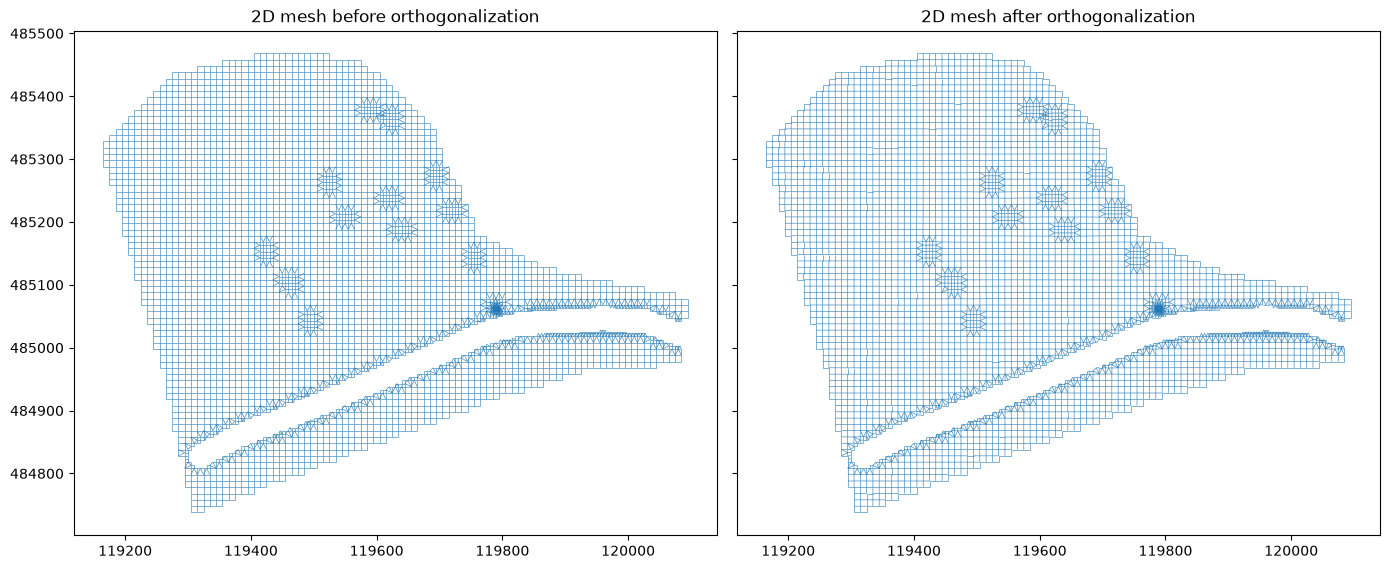

In [12]:
if TwoD:
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
    mesh2d_before.plot_edges(ax0, color="#1f77b4", linewidth=0.4)
    mesh2d_after.plot_edges(ax1, color="#1f77b4", linewidth=0.4)
    ax0.set_title("2D mesh before orthogonalization")
    ax1.set_title("2D mesh after orthogonalization")
    for ax in (ax0, ax1):
        ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

In [13]:
# --- Classify 1D-2D links by contact type ---
# hydrolib-core hard-codes link1d2d_contact_type to 3 for every link. Override that
# property so any link whose 1D node is a J_* manhole is written as streetInlet
# (type 5); all other links stay type 3. This is what ends up in network.nc.
# `snapped` (built in the mesh cell) holds the 1D mesh-node indices of the J_* manholes.
from hydrolib.core.dflowfm.net.models import Link1d2d

if TwoD:
    manhole_nodes = set(int(i) for i in snapped)   # J_* storage-node 1D mesh nodes

    def _link1d2d_contact_type(self):
        n1d = self.link1d2d[:, 0]                   # 1D mesh-node index of each link
        manholes = getattr(self, "_manhole_nodes", set())
        is_manhole = (
            np.isin(n1d, list(manholes)) if manholes else np.zeros(n1d.shape, dtype=bool)
        )
        return np.where(is_manhole, 5, 3).astype(np.int32)   # 5 = streetInlet, 3 = standard

    # attach the manhole node set and override the (otherwise hard-coded) property
    network._link1d2d._manhole_nodes = manhole_nodes
    Link1d2d.link1d2d_contact_type = property(_link1d2d_contact_type)

    # report the resulting classification (this is what will be written to network.nc)
    ct = network._link1d2d.link1d2d_contact_type
    labels = {3: "standard", 5: "streetInlet (manhole J_*)"}
    vals, counts = np.unique(ct, return_counts=True)
    print("1D-2D links by contact type:")
    for v, c in zip(vals, counts):
        print(f"  type {int(v)}: {c} links  ({labels.get(int(v), '?')})")
    print(f"  total       : {ct.shape[0]} links")
else:
    print("No 2D mesh / 1D-2D links created (TwoD is False).")


1D-2D links by contact type:
  type 3: 364 links  (standard)
  type 5: 13 links  (streetInlet (manhole J_*))
  total       : 377 links



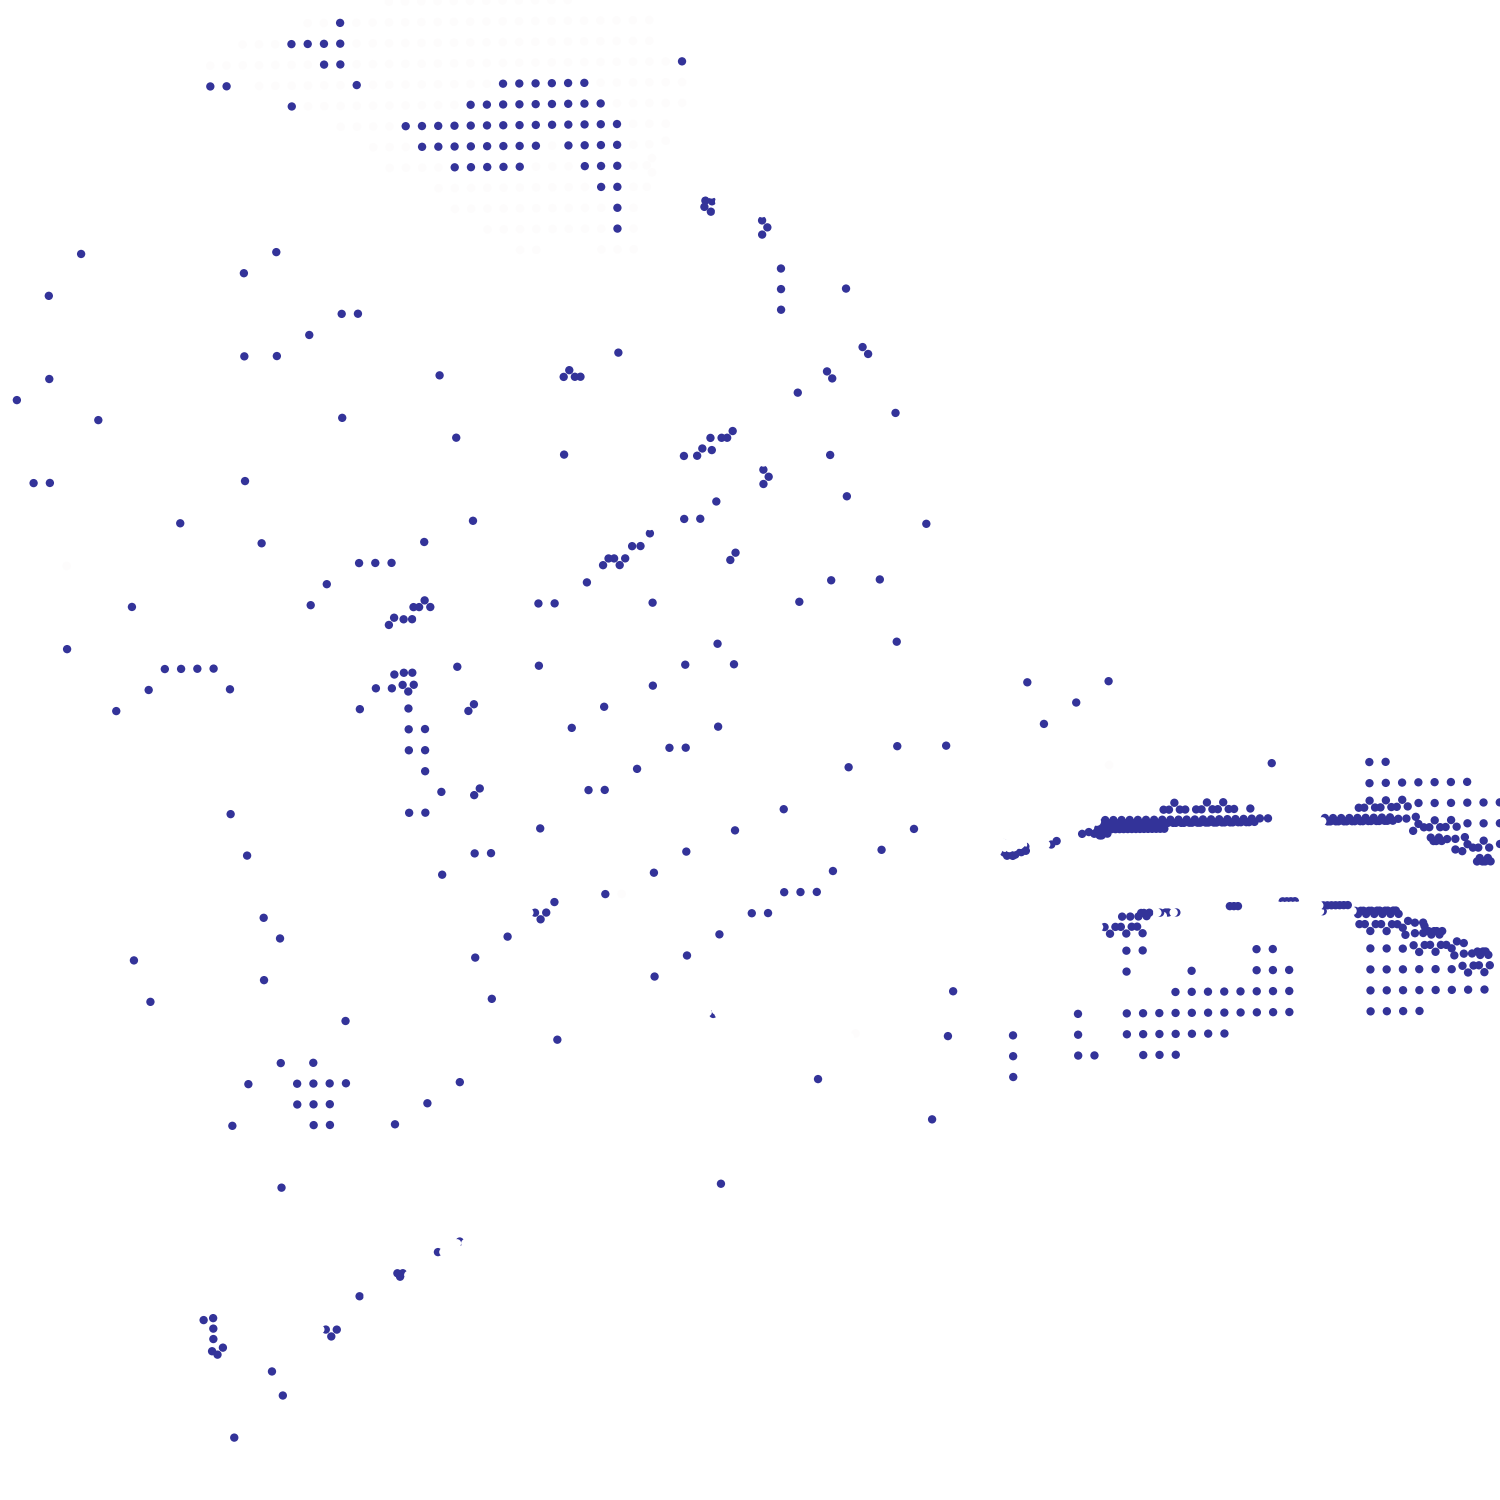

In [14]:
network = fm.geometry.netfile.network
m  = plot_network(network,face_z_kwargs={"cmap": 'terrain', "radius": 4.})
m

In [15]:
# --- map extent from the loaded model components ---
# The template notebook loads branches without a clip geometry, so hydamo.clipgeo
# is None. Derive the extent from the branches (falling back to any other loaded
# layer) so the map zooms to the data.
extent_gs = hydamo.branches.geometry.set_crs(28992).to_crs(4326)
b = extent_gs.total_bounds  # [minx, miny, maxx, maxy]

m = folium.Map(tiles="OpenStreetMap", width=1000)
m.fit_bounds([[b[1], b[0]], [b[3], b[2]]])

# --- line layers ---
folium.GeoJson(
    hydamo.branches.geometry.set_crs(28992).to_crs(4326),
    name="Channel",
    style_function=lambda _: {"color": "blue", "weight": 2},
).add_to(m)

if len(hydamo.profile) > 0:
    folium.GeoJson(
        hydamo.profile.geometry.set_crs(28992).to_crs(4326),
        name="Cross section",
        style_function=lambda _: {"color": "black", "weight": 4},
    ).add_to(m)

# --- storage: hydamo.storage_areas mixes storagenode points and storagearea
# polygons, so split on geometry type. Polygons are drawn as a filled layer;
# point_layer() only renders points. set_data() leaves .crs as None, hence the
# explicit crs= when rebuilding the polygon frame.
storage_polys = hydamo.storage_areas[
    hydamo.storage_areas.geom_type.isin(["Polygon", "MultiPolygon"])
]
storage_points = hydamo.storage_areas[hydamo.storage_areas.geom_type == "Point"]

if len(storage_polys) > 0:
    folium.GeoJson(
        gpd.GeoDataFrame(
            storage_polys[["code", "geometry"]], geometry="geometry", crs=28992
        ).to_crs(4326),
        name="Storage area",
        style_function=lambda _: {
            "color": "purple",
            "weight": 2,
            "fillColor": "purple",
            "fillOpacity": 0.3,
        },
        tooltip=folium.GeoJsonTooltip(fields=["code"]),
    ).add_to(m)

# --- point layers (only drawn when the layer holds features) ---
if len(hydamo.culverts) > 0:
    point_layer(m, hydamo.culverts,            "Culvert",  "brown",  "▲", size=16, use_centroid=True)
# point_layer(m, hydamo.weirs,                "Weir",     "green",  "▲", size=14)
# point_layer(m, hydamo.bridges,              "Bridge",   "red",    "▲", size=12)
if len(hydamo.pumpstations) > 0:
    point_layer(m, hydamo.pumpstations,        "Pump",     "orange", "□", size=18)
if len(hydamo.boundary_conditions) > 0:
    point_layer(m, hydamo.boundary_conditions, "Boundary", "red",    "▢", size=18)
if len(storage_points) > 0:
    point_layer(m, storage_points,             "Storage node", "purple", "●", size=14)

folium.LayerControl().add_to(m)
m

In [16]:
# Add externals
# only constant boundary conditions
# timeseries discharge boundary and q-h relation boundary must be added through `hydamo.external_forcings.add_boundary_condition`
hydamo.external_forcings.convert.boundaries(hydamo.boundary_conditions, mesh1d=fm.geometry.netfile.network)
hydamo.dict_to_dataframe(hydamo.external_forcings.boundary_nodes)

# Global default depth for all branches (the C_* conduits). Df2HydrolibModel
# turns this into the OneDFieldGlobal in models.onedfieldmodels.
hydamo.external_forcings.set_initial_waterdepth(0.0)

# Per-branch overrides. Df2HydrolibModel has no code path that emits
# OneDFieldBranch, so these are merged into the OneDFieldModel in the
# conversion cell below.
initial_depth_branches = [
    OneDFieldBranch(branchid="R_1", numlocations=0, values=[0.80]),
    OneDFieldBranch(branchid="R_2", numlocations=0, values=[0.60]),
]

In [17]:
if RR:
    # lu_file = data_path / "rasters" / "sobek_landuse.tif"
    # ahn_file = data_path / "rasters" / "AHN_2m_clipped_filled.tif"
    # soil_file = data_path / "rasters" / "sobek_soil.tif"     # not required for paved region
    surface_storage = 10.0 # [mm]                              # ponding depth before runoff
    infiltration_capacity = 100.0 # [mm/hr]                    
    initial_gwd = 1.2  # water level depth below surface [m]   # initial ground water depth
    runoff_resistance = 0.5 # [d]                              # runoff resistance from surface to open water
    infil_resistance = 300.0 # [d]                             # infiltration rate from open water to ground
    layer_depths = [0.0, 1.0, 2.0] # [m]
    layer_resistances = [30, 200, 10000] # [d]                 # infiltration rate from ground to open water

    meteo_areas = hydamo.catchments      # meteo areas are assumed to be catchments

    # unpaved nodes
    drrmodel.unpaved.io.unpaved_from_input(
        hydamo.catchments,
        lu_file,
        ahn_file,
        soil_file,
        surface_storage,
        infiltration_capacity,
        initial_gwd,
        meteo_areas,
        greenhouse_areas=hydamo.greenhouse_areas,

    )
    drrmodel.unpaved.io.ernst_from_input(
        hydamo.catchments,
        depths=layer_depths,
        resistance=layer_resistances,
        infiltration_resistance=infil_resistance,
        runoff_resistance=runoff_resistance,
    )
 
    street_storage = 5.0 # [mm]
    sewer_storage = 5.0 # [mm]
    poc_mmh  = data_path / 'rasters/pumpcap.tif'

    # simple paved areas
    # drrmodel.paved.io.paved_from_input(
    #         catchments=hydamo.catchments,
    #         landuse=lu_file,
    #         surface_level=ahn_file,
    #         street_storage=street_storage,
    #         sewer_storage=sewer_storage,
    #         pump_capacity=pumpcapacity,
    #         meteo_areas=meteo_areas,
    #         zonalstats_alltouched=True,
    # )

    # complex paved areas
    hydamo.sewer_areas.read_shp(str(data_path / 'rioleringsgebieden.shp'), index_col='code', column_mapping={'Code':'code', 'Berging_mm':'riool_berging_mm', 'POC_m3s':'riool_poc_m3s' })
    hydamo.overflows.read_shp(str(data_path / 'overstorten.shp'), column_mapping={'codegerela': 'codegerelateerdobject'})
    hydamo.overflows.snap_to_branch(hydamo.branches, snap_method="overal", maxdist=1100)
    drrmodel.paved.io.paved_from_input(
        catchments=hydamo.catchments,
        landuse=lu_file,
        surface_level=ahn_file,
        sewer_areas=hydamo.sewer_areas,
        overflows=hydamo.overflows,
        street_storage=street_storage,
        sewer_storage=sewer_storage,
        pump_capacity=poc_mmh,
        meteo_areas=meteo_areas,
        zonalstats_alltouched=True,
    )

    # open water areas
    drrmodel.openwater.io.openwater_from_input(
        hydamo.catchments, lu_file, meteo_areas, zonalstats_alltouched=True
    )

    # greenhouse nodes
    roof_storage = 5.0 # [mm]
    basin_storage_class = 3 # default class
    hydamo.greenhouse_areas.read_gpkg_layer( data_path / 'greenhouses.gpkg', layer_name='greenhouses', index_col='code')
    hydamo.greenhouse_laterals.read_gpkg_layer(data_path / 'greenhouse_laterals.gpkg', layer_name='laterals')
    hydamo.greenhouse_laterals.snap_to_branch(hydamo.branches, snap_method="overal", maxdist=1100)
    hydamo.greenhouse_areas['roof_storage_mm'] = roof_storage 
    hydamo.greenhouse_areas['basin_storage_class'] = [i+1 for i in range(hydamo.greenhouse_areas.shape[0])]
    
    drrmodel.greenhouse.io.greenhouse_from_input(
        catchments=hydamo.catchments,
        landuse=lu_file,
        surface_level=ahn_file,
        greenhouse_areas=hydamo.greenhouse_areas,
        greenhouse_laterals=hydamo.greenhouse_laterals,
        roof_storage=roof_storage,
        basin_storage_class=basin_storage_class,
        meteo_areas=meteo_areas,
        zonalstats_alltouched=True            
    )

    # RR boundaries
    drrmodel.external_forcings.io.boundary_from_input(
        hydamo.laterals, 
        hydamo.catchments, 
        drrmodel, 
        overflows=hydamo.overflows, 
        greenhouse_laterals=hydamo.greenhouse_laterals
    )

In [18]:
# Convert D-HyDAMO dataset to Hydrolib objects
models = Df2HydrolibModel(hydamo, assign_default_profiles=True)

# Migrate Hydrolib objects into Delft3D model
fm.geometry.structurefile = [StructureModel(structure=models.structures)]
fm.geometry.crosslocfile = CrossLocModel(crosssection=models.crosslocs)
fm.geometry.crossdeffile = CrossDefModel(definition=models.crossdefs)
fm.geometry.storagenodefile = StorageNodeModel(storagenode=models.storagenodes)

# observation points (only wire the output file if any were added)
if len(models.obspoints) > 0:
    fm.output.obsfile = [ObservationPointModel(observationpoint=models.obspoints)]

fm.geometry.frictfile = []
for i, fric_def in enumerate(models.friction_defs):
    fric_model = FrictionModel(global_=fric_def)
    fric_model.filepath = f"roughness_{i}.ini"
    fm.geometry.frictfile.append(fric_model)

extmodel = ExtModel()
extmodel.boundary = models.boundaries_ext
extmodel.lateral = models.laterals_ext
fm.external_forcing.extforcefilenew = extmodel

rain_forcing = ForcingModel(forcing=[TimeSeries(
    name="global",
    function="timeseries",
    timeinterpolation="block-To",
    quantityunitpair=[
        QuantityUnitPair(quantity="time", unit="minutes since 2016-06-01 00:00:00"),
        QuantityUnitPair(quantity="rainfall", unit="mm day-1"),
    ],
    datablock=[[0.0, 0.0], [2880.0, 0.0]],
)])
rain_forcing.filepath = Path("rainfall.bc")
extmodel.meteo = [Meteo(
    quantity="rainfall",
    forcingfile=rain_forcing,
    forcingfiletype=MeteoForcingFileType.bcascii,
)]

fm.geometry.inifieldfile = IniFieldModel(initial=models.inifields)

# storage node depths need row.branch_id/branch_offset, which only exist after
# snap_to_branch, so build these here rather than in the external-forcings cell.
storagenode_branches = [
    OneDFieldBranch(
        branchid=row.branch_id,
        numlocations=1,
        chainage=[row.branch_offset],
        values=[2.0],   # per-node depth [m]
    )
    for _, row in hydamo.storage_areas.iterrows()
]

for ifield, onedfield in enumerate(models.onedfieldmodels):
    # eventually this is the way, but it has not been implemented yet in Hydrolib core
    # fm.geometry.inifieldfile.initial[ifield].datafile = OneDFieldModel(global_=onedfield)

    # this is a workaround to do the same. The converter only produces the
    # global default, so the per-branch entries are attached here.
    onedfield_filepath = Path(output_path) / "dflowfm" / "initialwaterdepth.ini"
    onedfield_filepath.parent.mkdir(parents=True, exist_ok=True)
    onedfieldmodel = OneDFieldModel(
        global_=onedfield,
        branch=initial_depth_branches + storagenode_branches,
    )
    onedfieldmodel.save(filepath=onedfield_filepath)
    fm.geometry.inifieldfile.initial[ifield].datafile = DiskOnlyFileModel(
        filepath=onedfield_filepath
    )

In [19]:
# # roughness
# fm.trachytopes.trtrou = "Y"                     # switch trachytopes on
# fm.trachytopes.trtdef = "roughness.ttd"         # class definitions (Manning n=0.10)
# fm.trachytopes.trtl   = "roughness.arl"         # class -> 2D net-link mapping
# fm.trachytopes.dttrt  = float(fm.time.dtuser)   # update step: must be a multiple of DtUser

# dfm = output_path / "dflowfm"
# dfm.mkdir(parents=True, exist_ok=True)
# shutil.copyfile(data_path / "trachytopes" / "roughness.ttd", dfm / "roughness.ttd")

# # roughness.arl: assign class 1 (fraction 1.0) to every 2D net-link midpoint
# mk = fm.geometry.netfile.network._mesh2d.meshkernel.mesh2d_get()
# lines = [f"{x:.6f} {y:.6f} 0 1 1.0" for x, y in zip(mk.edge_x, mk.edge_y)]
# (dfm / "roughness.arl").write_text("\n".join(lines) + "\n")

In [20]:
# infiltration
# soil_file = data_path / "rasters" / "soil_map.tif"
# CAP = {1: 20.0, 2: 5.0, 3: 1.0}          # soil class -> infiltration capacity [mm/hr]

# # sample the soil map at each 2D face centre (in-memory mesh) and reclassify to capacity
# m2d = fm.geometry.netfile.network._mesh2d.meshkernel.mesh2d_get()
# fx, fy = m2d.face_x, m2d.face_y
# with rasterio.open(soil_file) as src:
#     cls = np.array(list(src.sample(np.c_[fx, fy])), float).ravel()
# cap = np.select([cls == k for k in CAP], list(CAP.values()), default=5.0)

# # write the per-face capacity field into the model dir (x y capacity)
# dfm = output_path / "dflowfm"; dfm.mkdir(parents=True, exist_ok=True)
# (dfm / "infiltcap.xyz").write_text("\n".join(f"{x:.3f} {y:.3f} {c:.4f}" for x, y, c in zip(fx, fy, cap)) + "\n")

# # [grw]: constant-capacity infiltration (model 2), no groundwater flow
# fm.grw = GroundWater(groundwater=False, infiltrationmodel=InfiltrationMethod.ConstantInfiltrationCapacity)

# # old-style ext points the 'infiltrationcapacity' quantity at the .xyz samples
# ext_inf = ExtOldModel(forcing=[ExtOldForcing(
#     quantity=ExtOldQuantity.InfiltrationCapacity,
#     filename="infiltcap.xyz",
#     filetype=ExtOldFileType.Samples,        # 7 = samples (.xyz)
#     method=ExtOldMethod.AveragingSpace,     # 6 = averaging in space
#     operand=Operand.override,               # O
#     averagingtype=1, relativesearchcellsize=1.01,
# )])
# ext_inf.filepath = Path("infiltration.ext")     # written into dflowfm/ by recurse-save
# fm.external_forcing.extforcefile = ext_inf      # old ext; coexists with extforcefilenew

In [21]:
# model config
fm.geometry.bedlevtype = 1                      # 1: at cell center (tiles xz,yz,bl,bob=max(bl)), 2: at face (tiles xu,yu,blu,bob=blu), 3: at face (using mean node values), 4: at face 
fm.geometry.changestructuredimensions = False   # Change the structure dimensions in case these are inconsistent with the channel dimensions.
fm.volumetables.usevolumetables = True          # parameter setting advised by Deltares for better performance
fm.restart.restartfile     = None              # Option to set restart file, only from netCDF-file, hence: either *_rst.nc or *_map.nc.
fm.restart.restartdatetime = None              # Option to set restart time [YYYYMMDDHHMMSS], only relevant in case of restart from *_map.nc.
fm.output.outputdir =  'output'                # location for model output - should be 'output' to be recognized by the D-Hydro GUI
fm.output.ncformat = 4                         # parameter setting advised by Deltares for better performance
fm.output.ncnoforcedflush = True               # parameter setting advised by Deltares for better performance
fm.output.ncnounlimited = True                 # parameter setting advised by Deltares for better performance
fm.output.statsinterval  = [1]                        # add timing information to model output
fm.output.mapinterval = [1200.0, fm.time.tstart, fm.time.tstop]      # Map file output, given as 'interval' 'start period' 'end period' [s].
fm.output.hisinterval = [300., fm.time.tstart, fm.time.tstop]        # History output, given as 'interval' 'start period' 'end period' [s].
fm.output.wrimap_flow_analysis = True                                # write information for flow analysis
fm.external_forcing.rainfall = True
fm.output.wrimap_rain = True

# 1D timesteps must at least equal to smallest timestep of RR/RTC, o.w water balance problems may occur.
timesteps = []
if RR:
    timesteps.append(drrmodel.d3b_parameters['Timestepsize'])
if RTC:
    timesteps.append(drtcmodel.time_settings['step'])
if len(timesteps)>0 and fm.time.dtuser > np.min(timesteps):
    fm.time.dtuser = np.min(timesteps)

# Export the model
fm.filepath = Path(output_path) / "dflowfm" / "DFM.mdu"
dimr = DIMR()
dimr.component.append(
    FMComponent(name="DFM", workingDir=Path(output_path) / "dflowfm", model=fm, inputfile=fm.filepath)    
)
dimr.save(recurse=True)
if RTC:
    drtcmodel.write_xml_v1()
if RR:
    rr_writer = DRRWriter(drrmodel, output_dir=output_path, name="DFM", wwtp=(199000.0, 396000.0))
    rr_writer.write_all()
# replace run_dimr.bat path with local installed Delft3D FM
dimr = DIMRWriter(
    output_path=output_path, 
    dimr_path=str(r"G:\Deltares\D-HYDRO Suite 2026.02 1D2D\plugins\DeltaShell.Dimr\kernels\x64\bin\run_dimr.bat")
)
if not RR:
    drrmodel = None
if not RTC:
    drtcmodel = None
dimr.write_dimrconfig(fm, rr_model=drrmodel, rtc_model=drtcmodel)
dimr.add_crs(Path(output_path) / "dflowfm")
dimr.write_runbat(debuglevel=6) # , runlog=output_path / 'run.log') # add the last part to write DHYDRO logging to a file. Now it is printed to the terminal.
with open(output_path / 'dflowfm' / 'fieldfile.ini', 'r') as f:
    lines = f.readlines()
    newlines = ['dataFile            = initialwaterdepth.ini\n' if l.startswith('dataFile ') else l for l in lines]
with open(output_path / 'dflowfm' / 'fieldfile.ini', 'w') as f:
    f.writelines(newlines)
print("Done!")

Done!
